# TD — Annotation automatique avec des LLM (Hugging Face)

Ce notebook :
1. lit des fichiers texte dans un dossier,
2. découpe les textes en *chunks* en privilégiant les retours à la ligne / paragraphes,
3. lance une **annotation automatique** via LLM (Hugging Face Serverless Inference API),
4. compare **plusieurs prompts** et **plusieurs modèles**,
5. exporte les résultats (`.parquet` / `.csv`) et fournit quelques métriques simples (accord inter-modèles, distribution des labels).

> ⚠️ Conseil TD : commencez petit (ex. 2–3 fichiers, 30–50 chunks), puis augmentez.  
> ⚠️ Éthique / RGPD : ne mettez pas de données sensibles dans une API externe.


## 0) Installation & authentification

- Il vous faut un **token Hugging Face** (fine-grained, avec permission *Inference*).
- Mettez-le dans une variable d’environnement `HF_TOKEN` (recommandé), ou collez-le au moment du login.



In [2]:
!pip install huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 521.0/521.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.4/201.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 39.1 MB/s eta 0:00:00m eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 6.1 MB/s eta 0:00:00


In [2]:
# If needed (Colab / env vierge):
# %pip install -U huggingface_hub pandas tqdm python-dotenv pyarrow

import os
from pathlib import Path
import time
import json
import hashlib
import re

import pandas as pd
from tqdm.auto import tqdm

from huggingface_hub import login
from huggingface_hub import InferenceClient

HF_TOKEN = os.getenv("HF_TOKEN")  # recommandé: export HF_TOKEN=...
if HF_TOKEN:
    login(token=HF_TOKEN)  # no need to print it
else:
    print("⚠️ HF_TOKEN non trouvé. Faites: `%env HF_TOKEN=...` puis relancez, ou utilisez login(token='...').")


⚠️ HF_TOKEN non trouvé. Faites: `%env HF_TOKEN=...` puis relancez, ou utilisez login(token='...').


/home/crazyjeannot/Documents/cours/2025/TALL_CPES_25-26/.dev_TALL/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
%env HF_TOKEN=hf_kab53128fezkgfk......

In [4]:
HF_TOKEN = os.getenv("HF_TOKEN")  # recommandé: export HF_TOKEN=...
if HF_TOKEN:
    login(token=HF_TOKEN)  # no need to print it
else:
    print("⚠️ HF_TOKEN non trouvé. Faites: `export HF_TOKEN=...` puis relancez, ou utilisez login(token='...').")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## 1) Charger les textes depuis un dossier

Par défaut on lit `data_seance_14/` (fichiers `.txt`).  

In [5]:
# ⚙️ Chemin racine attendu:
# data_seance_14/
#   aventures/
#   sentimental/
DATA_DIR = Path("data_seance_14")
print("DATA_DIR =", DATA_DIR.resolve())

# --- PARAMS TD (safe pour HF free) ---
N_PER_LABEL = 10      # mets 50 si tu sais que tes quotas le permettent
CHUNK_WORDS = 512
MIN_WORDS = 200
SEED = 0

DATA_DIR = /home/crazyjeannot/Documents/cours/2025/TALL_CPES_25-26/seance_14/data_seance_14


In [6]:
def sample_gold_chunks_json(
    root_dir: str,
    labels=("aventures", "sentimental"),
    n_per_label: int = 10,          # mets 10 pour rester safe en free HF
    chunk_words: int = 512,
    min_words: int = 200,           # évite les micro-chunks
    seed: int = 0,
    exts=(".txt",),
) -> str:
    """
    Folder attendu:
      root_dir/
        aventures/    (10 .txt)
        sentimental/  (10 .txt)

    Retour: JSON (str) = liste de dicts:
      { "id": "...", "gold": "aventures|sentimental", "source": "...", "text": "..." }
    """
    import json
    import random
    import re
    from pathlib import Path

    rng = random.Random(seed)
    root = Path(root_dir)

    def read_text(path: Path) -> str:
        for enc in ("utf-8", "utf-8-sig", "cp1252", "latin-1"):
            try:
                return path.read_text(encoding=enc)
            except UnicodeDecodeError:
                continue
        # dernier recours
        return path.read_text(encoding="utf-8", errors="ignore")

    def iter_chunks_preserve_paragraphs(text: str):
        # normalise légèrement, mais garde les sauts de lignes
        text = text.replace("\r\n", "\n").replace("\r", "\n").strip()
        if not text:
            return

        # split par paragraphes (lignes vides)
        paras = [p.strip() for p in re.split(r"\n\s*\n+", text) if p.strip()]
        buf_paras = []
        buf_words = 0

        def flush():
            nonlocal buf_paras, buf_words
            if buf_paras and buf_words >= min_words:
                yield "\n\n".join(buf_paras).strip()
            buf_paras, buf_words = [], 0

        for p in paras:
            w = len(p.split())
            if w >= chunk_words:
                # paragraphe énorme -> on le tranche en segments de chunk_words
                words = p.split()
                i = 0
                while i < len(words):
                    seg = " ".join(words[i : i + chunk_words])
                    if len(seg.split()) >= min_words:
                        yield seg
                    i += chunk_words
                continue

            # si ajouter ce paragraphe dépasse la cible, on flush d'abord
            if buf_words and (buf_words + w) > chunk_words:
                for c in flush():
                    yield c

            buf_paras.append(p)
            buf_words += w

        # flush final
        for c in flush():
            yield c

    # 1) collecte tous les chunks candidats par label
    candidates = {lab: [] for lab in labels}

    for lab in labels:
        lab_dir = root / lab
        if not lab_dir.exists():
            raise FileNotFoundError(f"Dossier manquant: {lab_dir}")

        files = [p for p in lab_dir.rglob("*") if p.suffix.lower() in exts]
        if not files:
            raise FileNotFoundError(f"Aucun fichier {exts} trouvé dans {lab_dir}")

        for fp in files:
            txt = read_text(fp)
            for j, chunk in enumerate(iter_chunks_preserve_paragraphs(txt)):
                candidates[lab].append(
                    {
                        "id": f"{lab}__{fp.stem}__{j:04d}",
                        "gold": lab,
                        "source": str(fp),
                        "text": chunk,
                    }
                )

    # 2) sample équilibré
    sampled = []
    for lab in labels:
        if len(candidates[lab]) < n_per_label:
            raise ValueError(
                f"Pas assez de chunks pour '{lab}': {len(candidates[lab])} < {n_per_label} "
                f"(baisse min_words/chunk_words, ou ajoute des textes)."
            )
        rng.shuffle(candidates[lab])
        sampled.extend(candidates[lab][:n_per_label])

    rng.shuffle(sampled)
    return json.dumps(sampled, ensure_ascii=False, indent=2)


In [7]:
# ✅ utilise la fonction "sample_gold_chunks_json" (définie dans une cellule plus haut)
gold_json_str = sample_gold_chunks_json(
    root_dir=str(DATA_DIR),
    labels=("aventures", "sentimental"),
    n_per_label=N_PER_LABEL,
    chunk_words=CHUNK_WORDS,
    min_words=MIN_WORDS,
    seed=SEED,
    exts=(".txt",),
)

# JSON (string) -> liste de dicts
gold_items = json.loads(gold_json_str)

print(f"✅ {len(gold_items)} chunks échantillonnés "
      f"({N_PER_LABEL} aventures + {N_PER_LABEL} sentimental)")

# aperçu
print("Exemple item:")
print(json.dumps(gold_items[0], ensure_ascii=False, indent=2)[:800], "...")


✅ 20 chunks échantillonnés (10 aventures + 10 sentimental)
Exemple item:
{
  "id": "aventures__1905_Le-Rouge-Gustave_L-Espionne-du-grand-Lama__0002",
  "gold": "aventures",
  "source": "data_seance_14/aventures/1905_Le-Rouge-Gustave_L-Espionne-du-grand-Lama.txt",
  "text": "compagnon, Timothée Framm, c’est une personnalité bien connue de la colonie européenne. On ne sait au juste s’il est de nationalité anglaise ou américaine. En tout cas, il n’y a pas à s’y méprendre, c’est un Anglo-Saxon. – Que fait-il ? – Il a plus d’une corde à son arc. Il s’occupe de négoce et d’exploitations industrielles. Il a même été chargé, lors de la guerre, d’une mission par le gouvernement anglais. En outre, il s’occupe beaucoup de reportage : il envoie des correspondances aussi intéressantes qu’inexactes à divers journaux anglais et américains. – C’est un de tes confrères de la pr ...


## 2) Appeler l'API

In [8]:
import os, json, time, requests
from pathlib import Path

HF_TOKEN = os.environ["HF_TOKEN"]

API_URL = "https://router.huggingface.co/v1/chat/completions"
MODEL   = "google/gemma-2-2b-it:nebius"

# meta-llama/Llama-3.2-3B-Instruct:together
# google/gemma-2-2b-it:nebius
# Qwen/Qwen2.5-7B-Instruct:together

HEADERS = {
    "Authorization": f"Bearer {HF_TOKEN}",
    "Content-Type": "application/json",
}

LABEL_SCHEMA = {
    "type": "json_schema",
    "json_schema": {
        "name": "label_only",
        "schema": {
            "type": "object",
            "properties": {
                "label": {"type": "string", "enum": ["AVENTURES", "SENTIMENTAL"]}
            },
            "required": ["label"],
            "additionalProperties": False
        },
        "strict": True
    }
}


In [10]:
def hf_label_chunk(text: str) -> str:
    messages = [
        {"role": "system", "content": "Tu es un classifieur de genre romanesque."},
        {"role": "user", "content":
            "Classe l'extrait en AVENTURES ou SENTIMENTAL.\n"
            "Réponds STRICTEMENT en JSON, conforme au schéma.\n\n"
            f"EXTRAIT:\n{text}"
        },
    ]
    payload = {
        "model": MODEL,
        "messages": messages,
        "temperature": 0,
        "max_tokens": 30,
        "response_format": LABEL_SCHEMA,
    }
    r = requests.post(API_URL, headers=HEADERS, json=payload, timeout=90)
    r.raise_for_status()
    content = r.json()["choices"][0]["message"]["content"]
    return json.loads(content)["label"]

# ---- Charge tes 20 chunks gold (adapte le path si besoin)
preds = []
for ex in gold_items:
    pred = hf_label_chunk(ex["text"])
    preds.append({
        **ex,
        "pred": pred,
        "model": MODEL,
    })
    time.sleep(0.4)  # petit délai anti-rate-limit

out_path = Path("preds_first_run.json")
out_path.write_text(json.dumps(preds, ensure_ascii=False, indent=2), encoding="utf-8")
print("✅ écrit:", out_path, "| n =", len(preds))
print("exemple:", preds[0]["gold"], "->", preds[0]["pred"])


✅ écrit: preds_first_run.json | n = 20
exemple: aventures -> AVENTURES


## 3) Evaluation !

In [11]:
import json
from pathlib import Path
from collections import Counter

preds = json.loads(Path("preds_first_run.json").read_text(encoding="utf-8"))

# normalisation (au cas où)
def norm(x: str) -> str:
    return (x or "").strip().upper()

y_true = [norm(p["gold"]) for p in preds]
y_pred = [norm(p["pred"]) for p in preds]

labels = ["AVENTURES", "SENTIMENTAL"]

# Accuracy
correct = sum(t == p for t, p in zip(y_true, y_pred))
acc = correct / len(y_true) if y_true else 0.0
print(f"Accuracy: {correct}/{len(y_true)} = {acc:.3f}")

# Confusion matrix (2x2)
cm = {a: {b: 0 for b in labels} for a in labels}
for t, p in zip(y_true, y_pred):
    if t in labels and p in labels:
        cm[t][p] += 1

print("\nConfusion matrix (rows=true, cols=pred):")
print(f"{'':12s}{labels[0]:12s}{labels[1]:12s}")
for t in labels:
    print(f"{t:12s}{cm[t][labels[0]]:12d}{cm[t][labels[1]]:12d}")

# Precision / Recall / F1 par classe
def prf_for(pos_label: str):
    tp = cm[pos_label][pos_label]
    fp = sum(cm[t][pos_label] for t in labels if t != pos_label)
    fn = sum(cm[pos_label][p] for p in labels if p != pos_label)
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = (2*prec*rec)/(prec+rec) if (prec+rec) else 0.0
    return prec, rec, f1

print("\nPer-class metrics:")
for lab in labels:
    prec, rec, f1 = prf_for(lab)
    print(f"{lab:12s}  precision={prec:.3f}  recall={rec:.3f}  f1={f1:.3f}")

# Macro-F1
f1s = [prf_for(lab)[2] for lab in labels]
macro_f1 = sum(f1s) / len(f1s)
print(f"\nMacro-F1: {macro_f1:.3f}")

# (optionnel) voir les erreurs
errors = [p for p in preds if norm(p["gold"]) != norm(p["pred"])]
print(f"\nErrors: {len(errors)}/{len(preds)}")
if errors:
    print("Exemple erreur:")
    e = errors[0]
    print("id:", e["id"], "| gold:", e["gold"], "| pred:", e["pred"])
    print((e["text"][:400] + " ...").replace("\n", " "))


Accuracy: 17/20 = 0.850

Confusion matrix (rows=true, cols=pred):
            AVENTURES   SENTIMENTAL 
AVENTURES              8           2
SENTIMENTAL            1           9

Per-class metrics:
AVENTURES     precision=0.889  recall=0.800  f1=0.842
SENTIMENTAL   precision=0.818  recall=0.900  f1=0.857

Macro-F1: 0.850

Errors: 3/20
Exemple erreur:
id: aventures__1904_Le-Rouge-Gustave_L-Esclave-amoureuse__0023 | gold: aventures | pred: SENTIMENTAL
copeau le plus mince empochait les enjeux. On cite le cas d’un navire, le Majestic dont le mât de beaupré se trouva entièrement abattu par le bowie-knife des passagers au cours d’une traversée. De temps à autre, M. Growlson s’interrompait de cette agréable occupation pour passer la main dans la chevelure frisée de ses petites compagnes ou pour leur tirer amicalement les oreilles. Cette récréation  ...


## Travail en groupe (2–3 personnes)

### Étape 1 — Choisir 2 romans (5 min)
Choisissez **2 fichiers** :
- 1 roman dans `aventures/`
- 1 roman dans `sentimental/`

Notez :
- leurs noms de fichiers
- leur label “gold” (le dossier)

---

### Étape 2 — Annoter tous les chunks avec un LLM 
Pour chaque chunk, demandez au modèle de prédire **AVENTURES** ou **SENTIMENTAL**.

Stockez pour chaque chunk :
- `gold` (label du roman)
- `pred` (label du LLM)
- (optionnel) `raw` si vous voulez auditer les sorties

⚠️ Important : vous devez récupérer **uniquement le tag** (`AVENTURES` ou `SENTIMENTAL`) dans votre pipeline.

---

### Étape 3 — Agréger au niveau du roman
Pour chaque roman, calculez :

- `p_aventures = (# chunks prédits AVENTURES) / (nb total de chunks)`
- `p_sentimental = 1 - p_aventures`

Décision roman-level (règle simple) :
- si `p_aventures > 0.5` → roman prédit **AVENTURES**
- sinon → roman prédit **SENTIMENTAL**

---

### Étape 4 — Score 
Calculez au moins :
- accuracy **chunk-level**
- accuracy **roman-level** (sur vos 2 romans)


In [5]:
index = json.loads(Path("json_novels/index.json").read_text(encoding="utf-8"))
print("ex:", index[0])

ex: {'gold': 'AVENTURES', 'roman_id': '1900_Verne-Jules-_Seconde-patrie', 'json_path': '/home/crazyjeannot/Documents/cours/2025/TALL_CPES_25-26/seance_14/json_novels/AVENTURES__1900_Verne-Jules-_Seconde-patrie.json', 'n_chunks': 242, 'source': '/home/crazyjeannot/Documents/cours/2025/TALL_CPES_25-26/seance_14/data_seance_14/aventures/1900_Verne-Jules-_Seconde-patrie.txt'}


In [6]:
novel = json.loads(Path(index[0]["json_path"]).read_text(encoding="utf-8"))
texts = [c["text"] for c in novel["chunks"]]  # -> à envoyer au LLM

# CORRIGÉ

In [26]:
TARGET_SOURCE = "data_seance_14/aventures/1900_Verne-Jules-_Seconde-patrie.txt"

# retrouver l'entrée correspondante dans l'index
entry = next(e for e in index if Path(e["source"]).as_posix().endswith(TARGET_SOURCE))

print("✅ trouvé:", entry["roman_id"], "| gold:", entry["gold"], "| n_chunks:", entry["n_chunks"])
print("json_path:", entry["json_path"])

# charger le JSON du roman
novel = json.loads(Path(entry["json_path"]).read_text(encoding="utf-8"))

# ✅ LA LIGNE CLÉ (liste de chunks à envoyer au LLM)
texts = [c["text"] for c in novel["chunks"]]

print("✅ texts prêts:", len(texts))
print("Aperçu chunk 0:\n", texts[0][:400], "...")

✅ trouvé: 1900_Verne-Jules-_Seconde-patrie | gold: AVENTURES | n_chunks: 242
json_path: /home/crazyjeannot/Documents/cours/2025/TALL_CPES_25-26/seance_14/json_novels/AVENTURES__1900_Verne-Jules-_Seconde-patrie.json
✅ texts prêts: 242
Aperçu chunk 0:
 La belle saison arriva dès la seconde semaine d’octobre. Ce mois est le premier du printemps de la zone méridionale. L’hiver n’avait pas été très rigoureux sous cette latitude du dix-neuvième degré entre l’Équateur et le tropique du Capricorne. Les hôtes de la Nouvelle-Suisse allaient pouvoir reprendre leurs travaux accoutumés.Après onze ans passés sur cette terre, ce n’était pas trop tôt de cherc ...


In [28]:
import os, json, time, requests
from collections import Counter
from tqdm import tqdm

HF_TOKEN = os.environ.get("HF_TOKEN")
assert HF_TOKEN, "HF_TOKEN absent (fais %env HF_TOKEN=... ou os.environ['HF_TOKEN']=...)"

API_URL = "https://router.huggingface.co/v1/chat/completions"
MODEL   = "Qwen/Qwen2.5-7B-Instruct:together"

HEADERS = {"Authorization": f"Bearer {HF_TOKEN}", "Content-Type": "application/json"}

LABEL_SCHEMA = {
    "type": "json_schema",
    "json_schema": {
        "name": "label_only",
        "schema": {
            "type": "object",
            "properties": {"label": {"type": "string", "enum": ["AVENTURES", "SENTIMENTAL"]}},
            "required": ["label"],
            "additionalProperties": False
        },
        "strict": True
    }
}

def hf_label_chunk(text: str) -> str:
    payload = {
        "model": MODEL,
        "messages": [
            {"role": "system", "content": "Tu es un classifieur de genre romanesque."},
            {"role": "user", "content":
                "Classe l'extrait en AVENTURES ou SENTIMENTAL.\n"
                "Réponds STRICTEMENT en JSON conforme au schéma.\n\n"
                f"EXTRAIT:\n{text}"
            },
        ],
        "temperature": 0,
        "max_tokens": 30,
        "response_format": LABEL_SCHEMA,
    }
    r = requests.post(API_URL, headers=HEADERS, json=payload, timeout=90)
    r.raise_for_status()
    content = r.json()["choices"][0]["message"]["content"]
    return json.loads(content)["label"]

# --- run sur 10 chunks pour sanity-check ---
N = min(10, len(texts))
N = len(texts)
preds = []
for i in tqdm(range(N)):
    pred = hf_label_chunk(texts[i])
    preds.append(pred)
    time.sleep(0.4)  # anti-rate-limit soft

counts = Counter(preds)
p_av = counts["AVENTURES"] / N
roman_pred = "AVENTURES" if p_av > 0.5 else "SENTIMENTAL"

print("✅ Done")
print("model:", MODEL)
print("chunk preds:", counts)
print(f"p(AVENTURES) = {p_av:.2f}")
print("roman_pred:", roman_pred, "| gold:", novel["gold"])

# sauvegarde (optionnel)
out = {
    "roman_id": novel["roman_id"],
    "gold": novel["gold"],
    "model": MODEL,
    "n_chunks_scored": N,
    "chunk_preds": preds,
    "p_aventures": p_av,
    "roman_pred": roman_pred,
}
Path("sanitycheck_seconde_patrie_preds.json").write_text(json.dumps(out, ensure_ascii=False, indent=2), encoding="utf-8")
print("💾 saved: sanitycheck_seconde_patrie_preds.json")


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 242/242 [03:52<00:00,  1.04it/s]

✅ Done
model: Qwen/Qwen2.5-7B-Instruct:together
chunk preds: Counter({'AVENTURES': 231, 'SENTIMENTAL': 11})
p(AVENTURES) = 0.95
roman_pred: AVENTURES | gold: AVENTURES
💾 saved: sanitycheck_seconde_patrie_preds.json


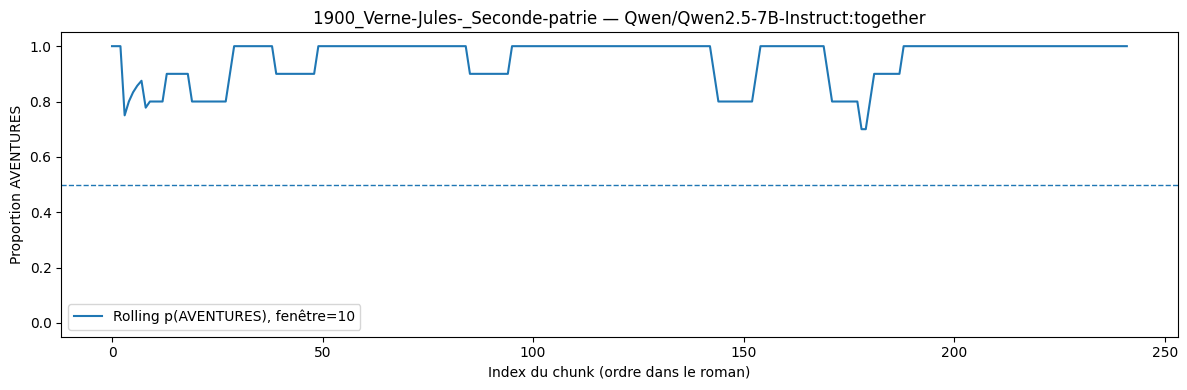

Counts: {'AVENTURES': 231, 'SENTIMENTAL': 11}
p(AVENTURES) globale = 0.955
Indices des chunks prédits SENTIMENTAL: [3, 8, 18, 19, 39, 85, 143, 144, 170, 171, 178] 


In [29]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# 1) Charger les prédictions roman-level
path = Path("sanitycheck_seconde_patrie_preds.json")
data = json.loads(path.read_text(encoding="utf-8"))

preds = data["chunk_preds"]  # liste ["AVENTURES", "SENTIMENTAL", ...]

# (robuste au cas où preds contiendrait des dicts)
if preds and isinstance(preds[0], dict):
    preds = [p["pred"] for p in preds]

df = pd.DataFrame({"chunk_idx": range(len(preds)), "pred": [p.upper().strip() for p in preds]})
df["is_aventures"] = (df["pred"] == "AVENTURES").astype(int)

# 2) Rolling + cumul
window = 10  # tu peux mettre 20 ou 30
df["p_av_roll"] = df["is_aventures"].rolling(window=window, min_periods=1).mean()
df["p_av_cum"]  = df["is_aventures"].expanding(min_periods=1).mean()

# 3) Plot
plt.figure(figsize=(12,4))
plt.plot(df["chunk_idx"], df["p_av_roll"], label=f"Rolling p(AVENTURES), fenêtre={window}")
#plt.plot(df["chunk_idx"], df["p_av_cum"], label="Cumulative p(AVENTURES)")
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.ylim(-0.05, 1.05)
plt.xlabel("Index du chunk (ordre dans le roman)")
plt.ylabel("Proportion AVENTURES")
plt.title(f"{data.get('roman_id','roman')} — {data.get('model','model')}")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Mini résumé + positions des chunks "SENTIMENTAL"
counts = df["pred"].value_counts().to_dict()
sent_idx = df.index[df["pred"] == "SENTIMENTAL"].tolist()

print("Counts:", counts)
print(f"p(AVENTURES) globale = {df['is_aventures'].mean():.3f}")
print("Indices des chunks prédits SENTIMENTAL:", sent_idx[:50], ("..." if len(sent_idx) > 50 else ""))


In [30]:
texts[3]

'père et de sa mère. Et puis, un autre sentiment avait contribué à modifier en mieux ses propensions naturelles.En effet, il ne pouvait oublier la jeune fille qu’il avait ramenée de la Roche-Fumante, et Jenny Montrose ne pouvait oublier qu’elle lui devait son salut. Jenny était charmante, avec ses cheveux blonds tombant en boucles soyeuses, sa taille flexible, ses mains fines, cette fraîcheur de carnation qui se reconnaissait sous le hâle de sa figure. En entrant dans cette honnête et laborieuse famille, elle lui avait apporté ce qui manquait jusqu’alors, la joie de la maison, et elle fut le bon génie du foyer domestique.Mais, si Ernest, Jack, François ne voyaient qu’une sœur dans cette aimable personne, en était-il ainsi de Fritz ?... Était-ce le même sentiment qui lui faisait battre le cœur ?... Et Jenny n’éprouvait-elle pas plus que de l’amitié pour le courageux jeune homme venu à son secours ?... Il s’était passé déjà près de deux ans depuis le si émouvant incident de la Roche-Fuma

### trouble shouting tqdm

In [13]:
!pip install --upgrade jupyter ipywidgets notebook jupyterlab_widgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 37.6 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 25.8 MB/s eta 0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 45.3 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 38.9 MB/s eta 0:00:00 MB/s eta 0:00:01
  Attempting uninstall: jupyterlab-server
    Found existing installation: jupyterlab_server 2.27.3
    Uninstalling jupyterlab_server-2.27.3:
      Successfully uninstalled jupyterlab_server-2.27.3
  Attempting uninstall: jupyterlab
    Found existing installation: jupyterlab 4.4.7
    Uninstalling jupyterlab-4.4.7:
      Successfully uninstalled jupyterlab-4.4.7


In [18]:
!jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


In [20]:
!jupyter labextension install @jupyter-widgets/jupyterlab-manager

(Deprecated) Installing extensions with the jupyter labextension install command is now deprecated and will be removed in a future major version of JupyterLab.

Users should manage prebuilt extensions with package managers like pip and conda, and extension authors are encouraged to distribute their extensions as prebuilt packages 
Building jupyterlab assets (production, minimized)
